<a href="https://colab.research.google.com/github/rambabuthadepalli123-beep/Musical-instrument-frequency-analyzer-/blob/main/Musical_instrument_frequency_analyzer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

       MUSICAL INSTRUMENT FREQUENCY ANALYZER

Number of masses       : 8
Mass of each mass     : 0.05 kg
Spring stiffness      : 100.0 N/m

Eigenvalues and Natural Frequencies
------------------------------------------------------------
Mode      Eigenvalue          Frequency (Hz)      
1         241.2295            2.4719              
2         935.8222            4.8687              
3         2000.0000           7.1176              
4         3305.4073           9.1502              
5         4694.5927           10.9048             
6         6000.0000           12.3281             
7         7064.1778           13.3768             
8         7758.7705           14.0190             


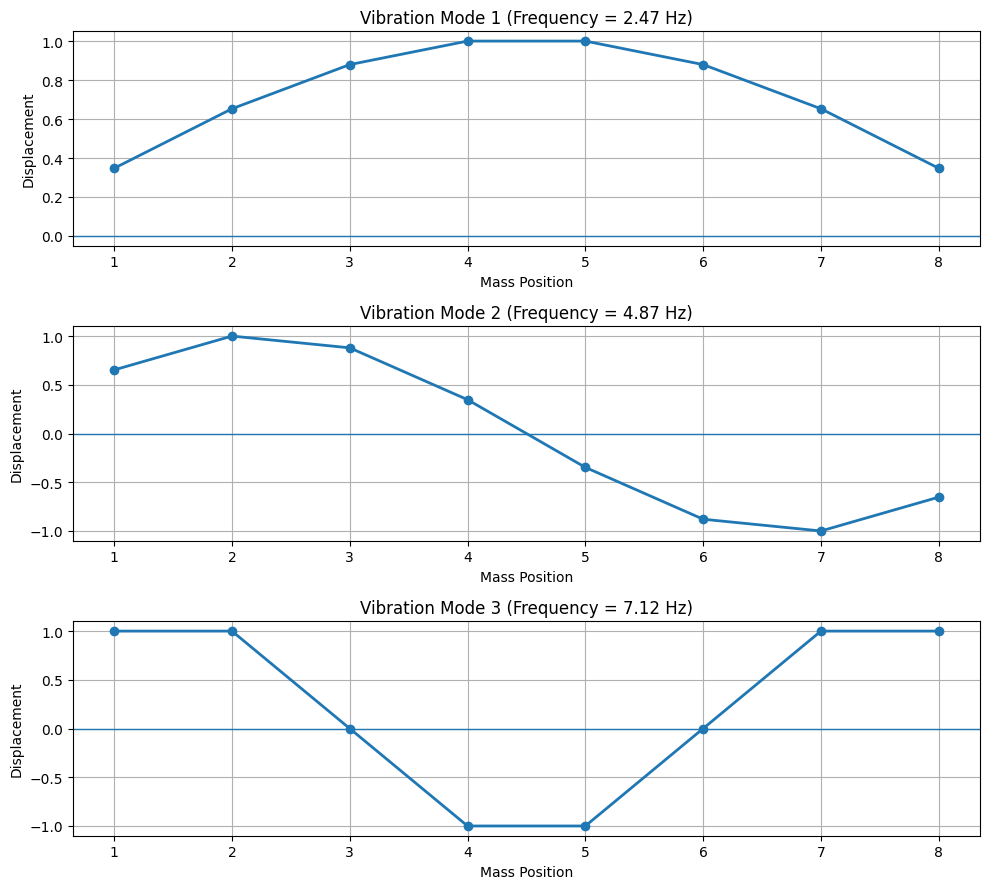


CONCLUSION

Eigenvalues represent the square of the natural angular
frequencies of the spring-mass system.

The natural frequency is obtained using:

    omega = sqrt(eigenvalue)

and

    f = omega / (2*pi)

The eigenvectors represent the vibration modes or shapes
of the system.

Therefore, eigenvalues tell us HOW FAST the system vibrates,
while eigenvectors tell us HOW the system vibrates.



In [ ]:
# ============================================================
# B4. MUSICAL INSTRUMENT FREQUENCY ANALYZER
# Eigenvalues and Vibration Modes
# Google Colab Project
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

# ------------------------------------------------------------
# 1. USER INPUTS
# ------------------------------------------------------------

# Number of masses in the spring-mass system
N = 8

# Mass of each small mass (kg)
mass = 0.05

# Spring stiffness (N/m)
spring_constant = 100.0

# Number of vibration modes to display
number_of_modes = 3


# ------------------------------------------------------------
# 2. INPUT VALIDATION
# ------------------------------------------------------------

if not isinstance(N, int) or N < 2:
    raise ValueError("N must be an integer greater than or equal to 2.")

if mass <= 0:
    raise ValueError("Mass must be greater than zero.")

if spring_constant <= 0:
    raise ValueError("Spring constant must be greater than zero.")

if number_of_modes < 1 or number_of_modes > N:
    raise ValueError("Number of modes must be between 1 and N.")


# ------------------------------------------------------------
# 3. CREATE MASS MATRIX M
# ------------------------------------------------------------

M = mass * np.eye(N)


# ------------------------------------------------------------
# 4. CREATE STIFFNESS MATRIX K
# ------------------------------------------------------------

K = np.zeros((N, N))

for i in range(N):
    K[i, i] = 2 * spring_constant

    if i > 0:
        K[i, i - 1] = -spring_constant

    if i < N - 1:
        K[i, i + 1] = -spring_constant


# ------------------------------------------------------------
# 5. SOLVE EIGENVALUE PROBLEM
#
# K φ = λ M φ
#
# Since M = mass * I:
# M^(-1)K φ = λ φ
# ------------------------------------------------------------

A = np.linalg.solve(M, K)

eigenvalues, eigenvectors = np.linalg.eigh(A)


# ------------------------------------------------------------
# 6. SORT EIGENVALUES AND EIGENVECTORS
# ------------------------------------------------------------

index = np.argsort(eigenvalues)

eigenvalues = eigenvalues[index]
eigenvectors = eigenvectors[:, index]


# ------------------------------------------------------------
# 7. CALCULATE NATURAL FREQUENCIES
# ------------------------------------------------------------

# Angular frequency:
# omega = sqrt(lambda)

omega = np.sqrt(np.maximum(eigenvalues, 0))

# Frequency in Hz:
# f = omega / (2*pi)

frequency = omega / (2 * np.pi)


# ------------------------------------------------------------
# 8. DISPLAY PROJECT INFORMATION
# ------------------------------------------------------------

print("=" * 60)
print("       MUSICAL INSTRUMENT FREQUENCY ANALYZER")
print("=" * 60)

print(f"\nNumber of masses       : {N}")
print(f"Mass of each mass     : {mass} kg")
print(f"Spring stiffness      : {spring_constant} N/m")

print("\nEigenvalues and Natural Frequencies")
print("-" * 60)

print(f"{'Mode':<10}{'Eigenvalue':<20}{'Frequency (Hz)':<20}")

for i in range(N):
    print(
        f"{i + 1:<10}"
        f"{eigenvalues[i]:<20.4f}"
        f"{frequency[i]:<20.4f}"
    )


# ------------------------------------------------------------
# 9. VISUALIZE FIRST VIBRATION MODES
# ------------------------------------------------------------

x = np.arange(1, N + 1)

fig, axes = plt.subplots(
    number_of_modes,
    1,
    figsize=(10, 3 * number_of_modes)
)

# If only one mode is selected, make axes iterable
if number_of_modes == 1:
    axes = [axes]

for mode in range(number_of_modes):

    shape = eigenvectors[:, mode]

    # Normalize the mode shape
    shape = shape / np.max(np.abs(shape))

    axes[mode].plot(
        x,
        shape,
        marker="o",
        linewidth=2
    )

    axes[mode].axhline(
        0,
        linewidth=1
    )

    axes[mode].set_title(
        f"Vibration Mode {mode + 1} "
        f"(Frequency = {frequency[mode]:.2f} Hz)"
    )

    axes[mode].set_xlabel("Mass Position")
    axes[mode].set_ylabel("Displacement")
    axes[mode].grid(True)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 10. ANIMATE THE FIRST VIBRATION MODE
# ------------------------------------------------------------

selected_mode = 0

mode_shape = eigenvectors[:, selected_mode]

# Normalize
mode_shape = mode_shape / np.max(np.abs(mode_shape))

fig, ax = plt.subplots(figsize=(10, 4))

ax.set_xlim(0.5, N + 0.5)
ax.set_ylim(-1.3, 1.3)

ax.set_xlabel("Mass Position")
ax.set_ylabel("Displacement")

ax.set_title(
    f"Animated Vibration - Mode {selected_mode + 1} "
    f"({frequency[selected_mode]:.2f} Hz)"
)

ax.grid(True)

line, = ax.plot(
    x,
    mode_shape,
    marker="o",
    linewidth=2
)


# Animation function
def animate(frame):

    # Create smooth oscillation
    displacement = mode_shape * np.sin(
        2 * np.pi * frame / 40
    )

    line.set_ydata(displacement)

    return line,


# Create animation
animation = FuncAnimation(
    fig,
    animate,
    frames=80,
    interval=50,
    blit=True
)

plt.close(fig)

display(HTML(animation.to_jshtml()))


# ------------------------------------------------------------
# 11. CONCLUSION
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("CONCLUSION")
print("=" * 60)

print("""
Eigenvalues represent the square of the natural angular
frequencies of the spring-mass system.

The natural frequency is obtained using:

    omega = sqrt(eigenvalue)

and

    f = omega / (2*pi)

The eigenvectors represent the vibration modes or shapes
of the system.

Therefore, eigenvalues tell us HOW FAST the system vibrates,
while eigenvectors tell us HOW the system vibrates.
""")